In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

path = kagglehub.dataset_download('nasa/kepler-exoplanet-search-results')

print('Path to dataset files:', path)

Using Colab cache for faster access to the 'kepler-exoplanet-search-results' dataset.
Path to dataset files: /kaggle/input/kepler-exoplanet-search-results


In [ ]:
import os

files_in_directory = os.listdir(path)

csv_file = [f for f in files_in_directory if f.endswith('.csv')]

if csv_file:
    full_csv_path = os.path.join(path, csv_file[0])
    df = pd.read_csv(full_csv_path)
    print(f'Successfully loaded data from: {full_csv_path}')
    df.head()
else:
    print(f'No CSV files found in the directory: {path}')

Successfully loaded data from: /kaggle/input/kepler-exoplanet-search-results/cumulative.csv


Loading in Kaggle Data set using provided code from Author.

In [ ]:
print('Target variable (koi_disposition) distribution:')
print(df['koi_disposition'].value_counts())

print(f'\nTotal planets: {len(df)}')
print(f'\nMissing values per column:')
print(df.isnull().sum().sort_values(ascending=False).head(20))


Target variable (koi_disposition) distribution:
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

Total planets: 9564

Missing values per column:
koi_teq_err2         9564
koi_teq_err1         9564
kepler_name          7270
koi_score            1510
koi_steff_err2        483
koi_srad_err2         468
koi_srad_err1         468
koi_steff_err1        468
koi_slogg_err2        468
koi_slogg_err1        468
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_period_err1       454
koi_period_err2       454
koi_impact_err2       454
koi_impact_err1       454
koi_depth_err1        454
koi_depth_err2        454
koi_duration_err1     454
koi_duration_err2     454
dtype: int64


Proportion Distribution of our Dataset's 3 classifications: False Positive, Candidate, and Confirmed

Missing Values per column; We noticed that koi_teq_err2, koi_teq_err, and kepler_name were missing significant values so we decided to drop these columns all together, as well as all objects that didn't have a koi_score as it was one of the highest correlating features of the data set. We thought it was suitable because we would still be left over 8000 objects of interest to build our model on

In [ ]:
columns_to_drop = ['kepler_name', 'koi_teq_err1', 'koi_teq_err2','koi_score']
df = df.drop(columns=columns_to_drop)

# df = df.dropna(subset=['koi_score'])

print(f'After dropping missing koi_score: {len(df)} planets remain')
print(f'\nNew target distribution:')
print(df['koi_disposition'].value_counts())

print(f'\nRemaining missing values:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

After dropping missing koi_score: 9564 planets remain

New target distribution:
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

Remaining missing values:
koi_steff_err2      483
koi_srad_err2       468
koi_slogg_err2      468
koi_srad_err1       468
koi_slogg_err1      468
koi_steff_err1      468
koi_impact_err1     454
koi_time0bk_err2    454
koi_time0bk_err1    454
koi_period_err2     454
dtype: int64


In [ ]:
def mark_planet(x):
    if x in ['CONFIRMED', 'CANDIDATE']:
        return 1
    else:
        return 0


This function allows us to proceed with binary classification methods by assigning both possible and confirmed planets as 1's indicating "planet", and False Negatives as 0's as non-planets

In [ ]:
df['is_planet'] = df['koi_disposition'].apply(mark_planet)

print('Target distribution: \n(1 = Planet, 0 = Non-Planet)')
print(df['is_planet'].value_counts())
print(f'\nPercentage of real planets: {df['is_planet'].mean()*100:.1f}%')

print(f'\nFinal dataset shape: {df.shape}')

Target distribution: 
(1 = Planet, 0 = Non-Planet)
is_planet
0    5023
1    4541
Name: count, dtype: int64

Percentage of real planets: 47.5%

Final dataset shape: (9564, 47)


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

threshold = 0.3 * len(df)
df = df.dropna(thresh=len(df) - threshold, axis=1)

df = df.fillna(df.median(numeric_only=True))

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('is_planet')
numeric_cols.remove('rowid')
numeric_cols.remove('kepid')

print(f'\nFeatures available: {len(numeric_cols)}')
print(f'Sample features: {numeric_cols[:10]}')

koi_steff_err2       483
koi_srad_err1        468
koi_srad_err2        468
koi_slogg_err1       468
koi_steff_err1       468
koi_slogg_err2       468
koi_time0bk_err1     454
koi_impact_err2      454
koi_impact_err1      454
koi_time0bk_err2     454
koi_period_err1      454
koi_period_err2      454
koi_duration_err2    454
koi_depth_err2       454
koi_depth_err1       454
koi_duration_err1    454
koi_slogg            363
koi_steff            363
koi_srad             363
koi_prad_err2        363
koi_prad_err1        363
koi_depth            363
koi_impact           363
koi_teq              363
koi_prad             363
koi_model_snr        363
koi_tce_plnt_num     346
koi_tce_delivname    346
koi_insol            321
koi_insol_err1       321
koi_insol_err2       321
koi_kepmag             1
dtype: int64

Features available: 40
Sample features: ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0

Here we are printing the remaining missing values after our first filter and then we are filling all of our missing values with the median value for their respective variable median values to have a data set with all non missing values

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


Import train_test_split for test and training data, and then RandomForestClassifier for our model prediction

In [ ]:
confirmed = df[df['koi_disposition'] == 'CONFIRMED'].copy()
false_positive = df[df['koi_disposition'] == 'FALSE POSITIVE'].copy()
candidates = df[df['koi_disposition'] == 'CANDIDATE'].copy()

print(f'Training data:')
print(f'  CONFIRMED: {len(confirmed)}')
print(f'  FALSE POSITIVE: {len(false_positive)}')
print(f'Total training samples: {len(confirmed) + len(false_positive)}')

print(f'\nPrediction targets (CANDIDATES): {len(candidates)}')

train_df = pd.concat([confirmed, false_positive])

def mark_confirmed(x):
    if x == 'CONFIRMED':
        return 1
    else:
        return 0

train_df['is_planet'] = train_df['koi_disposition'].apply(mark_confirmed
)





Training data:
  CONFIRMED: 2293
  FALSE POSITIVE: 5023
Total training samples: 7316

Prediction targets (CANDIDATES): 2248


At the start we make 3 copies of our originial data where the first data set is comprised of all Confirmed Exoplanets, the 2nd is all False Positive Exoplanets, and the 3rd, all Candidate Exoplanets

We then merge both the confirmed and false positive datasets into one dataframe called train_df which we will use as our training model data so we can then later predict on our candidate exoplanet data set.

The mark_confirmed function begins our training model by reassigning 'Confirmed' exoplanets to 1 for our binary classification setup.

In [ ]:
X = train_df[numeric_cols]
y = train_df['is_planet']

X_test, X_train, y_test, y_train = train_test_split(
    X, y, test_size=0.2, stratify=y)

X_candidates = candidates[numeric_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_candidates_scaled = scaler.transform(X_candidates)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

test_accuracy = rf.score(X_test_scaled, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')

train_accuracy = rf.score(X_train_scaled, y_train)
print(f'Training Accuracy: {train_accuracy:.4f}')


Test Accuracy: 0.9793
Training Accuracy: 1.0000


Random Forest Classifier

Randomness 1: bootstrapped sampling of training examples (rows).

Randomness 2: random sub-sampling of features at each split in each tree.

y is equal to our target variable (is_planet) (1s and 0s), while X is all of our indicator variables.

80% training 20% testing split

Random Forest has 100 trees in the forest meaning that it will take 100 random bootstrapped samples with 100 random subset of indicator variables (leaves) and model on our known data

Once we fit our Random Forest to our data we come out with a very high test accuracy (usually >0.97) and a 1.000 training accuracy. This does mean that our model has memorized the data set, but because our test accuracy is also very high it means that our model is extremely accurate

In [ ]:
candidates['predicted_planet'] = rf.predict(X_candidates_scaled)
candidates['planet_probability'] = rf.predict_proba(X_candidates_scaled)[:, 1]

print('PREDICTIONS FOR CANDIDATE EXOPLANETS')
print(f'Total candidates: {len(candidates)}')
print(f'\nPredicted as REAL PLANET: {candidates['predicted_planet'].sum()} ({candidates['predicted_planet'].mean()*100:.1f}%)')
print(f'Predicted as FALSE POSITIVE: {(1-candidates['predicted_planet']).sum()} ({(1-candidates['predicted_planet']).mean()*100:.1f}%)')

print('\nTop 10 most likely real planets (highest confidence):')
top_planets = candidates.nlargest(10, 'planet_probability')[['kepoi_name', 'planet_probability', 'predicted_planet']]
print(top_planets)

print('\nTop 10 most likely false positives (lowest confidence):')
top_false = candidates.nsmallest(10, 'planet_probability')[['kepoi_name', 'planet_probability', 'predicted_planet']]
print(top_false)

PREDICTIONS FOR CANDIDATE EXOPLANETS
Total candidates: 2248

Predicted as REAL PLANET: 1249 (55.6%)
Predicted as FALSE POSITIVE: 999 (44.4%)

Top 10 most likely real planets (highest confidence):
    kepoi_name  planet_probability  predicted_planet
153  K00841.03                 1.0                 1
210  K00892.02                 1.0                 1
303  K00935.04                 1.0                 1
483  K00141.01                 1.0                 1
574  K01085.01                 1.0                 1
613  K01030.01                 1.0                 1
645  K01165.01                 1.0                 1
671  K01239.02                 1.0                 1
845  K01276.01                 1.0                 1
846  K01276.02                 1.0                 1

Top 10 most likely false positives (lowest confidence):
     kepoi_name  planet_probability  predicted_planet
820   K01448.01                 0.0                 0
961   K01296.01                 0.0                 0
12

Here we use predict_proba() as the predict_proba method is used to predict class probabilities for classification models, returning the probability estimates for each class rather than the predicted class labels themselves(which is predict()).

This helps us in our next step of our analysis seeing which planets are most likely a planet versus those which are not.

Here we showcase the 10 most likely exoplanets from the Candidates data set and the 10 most unlikely exoplanets from the Candidates data set based off our training model

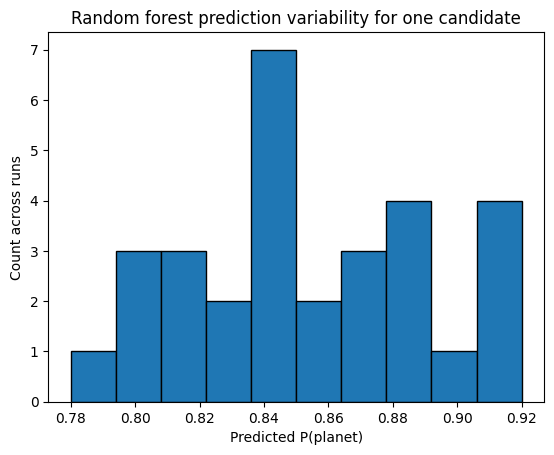

In [ ]:
n_runs = 30
probs = []

for seed in range(n_runs):
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=seed,
        class_weight='balanced'
    )
    rf.fit(X_train_scaled, y_train)
    p = rf.predict_proba(X_candidates_scaled)[0, 1]
    probs.append(p)

plt.hist(probs, bins=10, edgecolor='k')
plt.xlabel("Predicted P(planet)")
plt.ylabel("Count across runs")
plt.title("Random forest prediction variability for one candidate")
plt.show()

Shows us how much the predicted probability for a singular candidate wiggles across different random forests each time we run the RandomForestClassifier

We basically can run the prediction model over and over (increase n_runs) and normalize the probability results to see the 'true' probability of a Candidate being predicted Planet.


Because RandomForest is so robust and intensive, running it multiple times takes a lot of memory and results in slower run times


In [ ]:
n_runs = 50

X_scaled = scaler.fit_transform(X)

all_preds = []

for seed in range(n_runs):
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=seed,
        class_weight='balanced'
    )
    rf.fit(X_scaled, y)
    preds = rf.predict(X_candidates_scaled)
    all_preds.append(preds)

all_preds = np.stack(all_preds, axis=1)

planet_frac = all_preds.mean(axis=1)


flips = np.sum(np.diff(all_preds, axis=1) != 0, axis=1)

cand_stats = candidates[['kepoi_name']].copy()
cand_stats['planet_frac'] = planet_frac
cand_stats['flip_count'] = flips

flip_floppy = cand_stats.sort_values('flip_count', ascending=False)



Here we wanted to see which specific planets were most uncertain to be an exoplanet or a false positive, so we decided to meausure a candidates uncertainty by how many times it flipped from 'Confirmed' to 'False_Positive' or visa versa, as well as its 'true' probability for being predicted Planet over the course of many Random Forests.

all_preds takes all predictions (1 or 0) of any given candidate and then planet_frac is equal to the average of all predictions

We calculate flips by summing the total diff() !=0
diff() explanation: if n and n+1 are both equal to 1, diff will return 0, but if n is 1 and n+1 is 0, signifying a FLIP in prediction of planet or false_positive, diff() will return 1.

By summing all diff() we can count how many times any given Candidate switches from being predicted as a Confirmed exoplanet or a False_Postive over many Random Forests (50 in this case)

flip_floppy is a dataset containing average predicted planet probability and flip_count of all Candidates

In [ ]:
print(flip_floppy.head(10))
flip_floppy.loc[flip_floppy['flip_count']>=20]

     kepoi_name  planet_frac  flip_count
2256  K02626.01         0.44          31
1148  K01649.01         0.52          31
6328  K05406.01         0.46          31
3761  K04343.01         0.50          29
4631  K04810.01         0.56          29
1394  K02042.01         0.50          29
8070  K02564.02         0.50          28
2102  K02512.01         0.58          28
7703  K07072.01         0.52          28
7387  K04535.02         0.58          28


,kepoi_name,planet_frac,flip_count
2256,K02626.01,0.44,31
1148,K01649.01,0.52,31
6328,K05406.01,0.46,31
3761,K04343.01,0.50,29
4631,K04810.01,0.56,29
...,...,...,...
4275,K04587.01,0.78,20
6977,K06104.01,0.26,20
6554,K05842.01,0.22,20
7794,K06687.01,0.62,20


Here we have Candidates with the highest flip_count

<Axes: xlabel='planet_frac', ylabel='flip_count'>

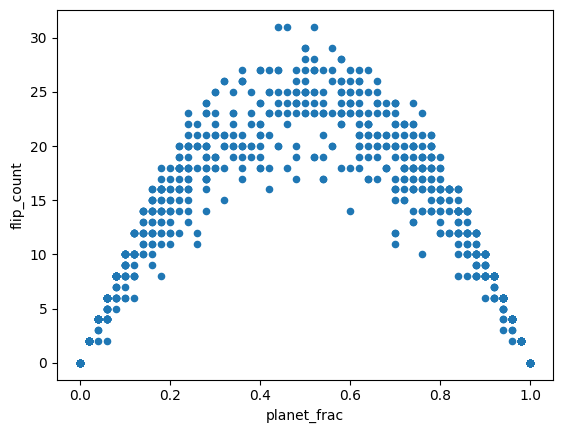

In [ ]:
flip_floppy.plot(kind='scatter', x='planet_frac', y='flip_count')


Noticed that the relationship between planet_frac and flip_count looks like a parabola with a negative coeffecient meaning that they have a quadratic relationshio

Candidates with the highest flip_count seemingly have a planet_frac ~0.5, while lower flip counts tend towards 0.0 and 1.0

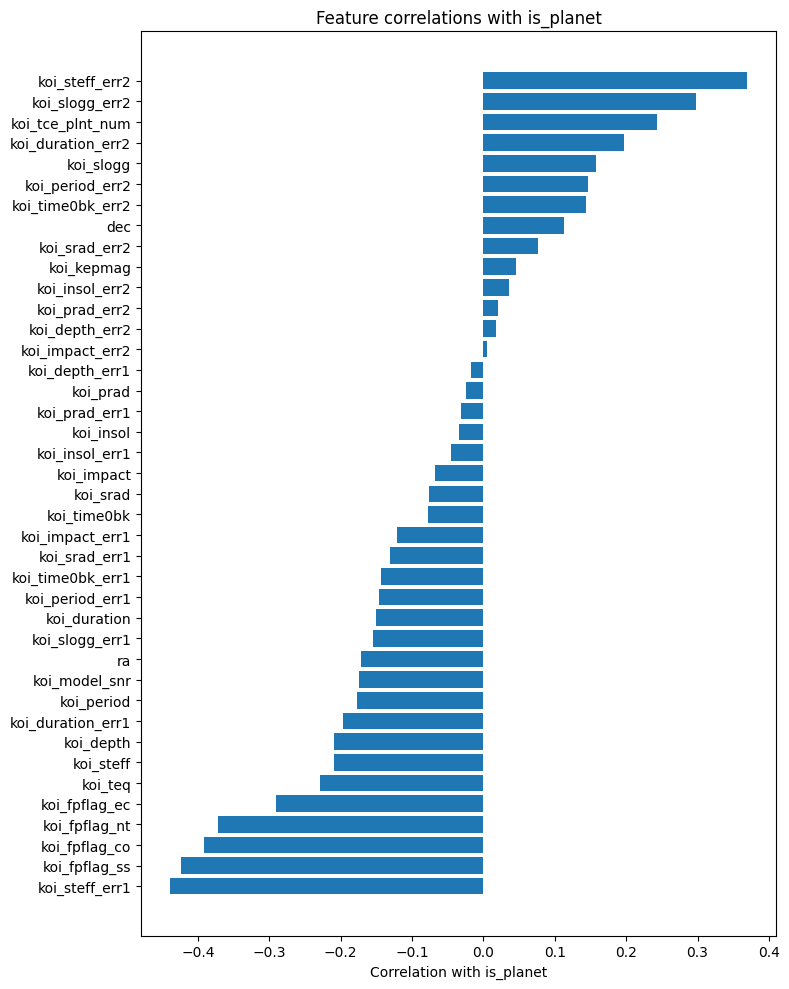

In [ ]:
corr_with_planet = train_df[numeric_cols].corrwith(train_df['is_planet'])
corr_sorted = corr_with_planet.sort_values()

plt.figure(figsize=(8, 10))
plt.barh(corr_sorted.index, corr_sorted.values)
plt.xlabel("Correlation with is_planet")
plt.title("Feature correlations with is_planet")
plt.tight_layout()
plt.show()


Strongest Positive Correlations:

Koi_score has the strongest positive correlation because it is an already computed value by NASA which gives a value between 0 and 1 that indicates the confidence in the disposition of a Kepler Object of Interest (Real Planet or Not)


**Real planets are often found around fainter stars that have imprecise measurements (large errors)**

(+) koi_steff_err2
(+) koi_slogg ( _err2 )
(+) koi_duration_err2

Strongest Negative Correlations

**fpflags (co, ec, ss) are red flags suggesting it's NOT a real planet**

(-) koi_fpflag_co
(-) koi_fpflag_ec
(-) koi_fpflag_ss


In [ ]:
flip_floppy.loc[flip_floppy['planet_frac'] == 0]

,kepoi_name,planet_frac,flip_count
9494,K08089.01,0.0,0
72,K00799.01,0.0,0
9362,K08063.01,0.0,0
9373,K08275.01,0.0,0
9374,K08276.01,0.0,0
...,...,...,...
9526,K07982.01,0.0,0
9523,K07978.01,0.0,0
9515,K08280.01,0.0,0
9558,K03891.01,0.0,0
